# 实验介绍

实验改编自《深度学习框架PyTorch：入门与实践（陈云）》中《AI 诗人：用 RNN写诗》。参考：https://github.com/chenyuntc/pytorch-book.git  

本实验基于改编后的charRNN进行训练，生成古诗。古诗生成有两种方式：生成藏头诗和续写古诗。

**实验任务**

1. 完成环境配置和pytorch使用，对原始数据进行预处理，生成numpy的压缩包tang.npz（30%）  
2. 从底层构建LSTM，自行调节相关参数进行训练，窗口保留打印的训练日志，并生成loss.png（完整构建多层LSTM占40%，只构建单层LSTM占30%）  
3. 基于训练后的模型，测试生成藏头诗和续写诗歌（每个占10%， 共占20%）
4. 调用大语言模型生成古诗生成和测试困惑度（10%） 

# 环境配置和pytorch使用

环境配置

创建conda虚拟环境 

```python
conda create -n poetry python=3.9 -y
conda activate poetry
```

安装pytorch：在 [pytorch官网](https://pytorch.org/) install部分，根据你的硬件条件选择对应的安装命令。例如：
```python
pip3 install torch torchvision torchaudio
```

安装numpy, pandas, matplotlib, tqdm, opencc-python-reimplemented

In [ ]:
%pip install numpy pandas matplotlib tqdm opencc-python-reimplemented

导入库

In [1]:
import os
import re
import json
import math
from tqdm import tqdm
import numpy as np
from opencc import OpenCC

import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as Data
from torch.utils.data import random_split, DataLoader
import torch.nn.functional as F
from torch.autograd import Variable
import matplotlib.pyplot as plt


In [2]:
print("PyTorch version:", torch.__version__)

PyTorch version: 2.12.1+cu126


**pytorch使用**

1. 张量（tensor）   
张量是pytorch最基本的数据结构，类似于numpy.ndarray，可以挂载到GPU上加速计算。

In [3]:
# TODO: 创建一个2×2的张量x
x = torch.tensor([[1, 2], [3, 4]])
print(x)

# TODO: 创建一个形状为(2,3)的张量rand_x并随机初始化
rand_x = torch.rand(2, 3)
print(rand_x)

# 张量运算
y = x + 2
z = x * y  # 逐元素相乘
print(z)

# TODO: 检测GPU并将张量z移动到设备上
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
z = z.to(device)
print(z)


tensor([[1, 2],
        [3, 4]])
tensor([[0.9259, 0.5291, 0.6363],
        [0.6789, 0.3516, 0.7585]])
tensor([[ 3,  8],
        [15, 24]])
tensor([[ 3,  8],
        [15, 24]], device='cuda:0')


2. 自动求导（Autograd）  
pytorch具有自动求导功能，支持反向传播。   

In [4]:
x = torch.randn(3, requires_grad=True)  # requires_grad表示是否需要计算梯度
print(x)
y = x * 2
z = y.mean()  # 计算均值

# TODO: 在此添加反向传播代码，计算梯度
z.backward()  

# TODO: 输出x的梯度
print(x.grad)


tensor([1.1065, 0.8789, 0.1189], requires_grad=True)
tensor([0.6667, 0.6667, 0.6667])


3. 神经网络模块（nn.Module）  
pytorch提供了一个`nn.Module`类，用于构建神经网络。通过继承这个类，我们可以定义自己的网络结构。

In [5]:
class SimpleNet(nn.Module):
    def __init__(self):
        super(SimpleNet, self).__init__()
        self.fc1 = nn.Linear(10, 5)  # 输入层到隐藏层
        self.fc2 = nn.Linear(5, 2)   # 隐藏层到输出层

    def forward(self, x):
        # TODO: 补全前向传播过程
        # 通过fc1后，使用ReLU激活函数，然后通过fc2
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        
        return x

net = SimpleNet()
print(net)

SimpleNet(
  (fc1): Linear(in_features=10, out_features=5, bias=True)
  (fc2): Linear(in_features=5, out_features=2, bias=True)
)


4. 训练：损失函数，优化器，前向传播+反向传播

In [6]:
# TODO: 选择损失函数
# 分类任务常用CrossEntropyLoss，回归任务常用MSELoss
criterion = nn.CrossEntropyLoss()  


# TODO: 选择优化器
# 简单小规模任务SGD随机梯度下降
optimizer = torch.optim.SGD(net.parameters(), lr=0.01)  


In [7]:
# 创建输入和目标张量
inputs = torch.randn(4, 10)
targets = torch.randn(4, 2)

# 前向传播
outputs = net(inputs)
print("Outputs:", outputs)

# TODO: 计算损失
loss = criterion(outputs, targets)
print("Loss:", loss.item())

# TODO: 后向传播
# 清除之前的梯度；计算梯度；更新参数
optimizer.zero_grad()  # 清除之前的梯度
loss.backward()        # 计算梯度
optimizer.step()       # 更新参数

print("Updated network parameters:")
for name, param in net.named_parameters():
    print(name, param.detach())

Outputs: tensor([[-0.1962, -0.5441],
        [-0.6055, -0.4436],
        [-0.2275, -0.1737],
        [-0.5857, -0.3309]], grad_fn=<AddmmBackward0>)
Loss: -0.35397225618362427
Updated network parameters:
fc1.weight tensor([[-0.1909,  0.2578, -0.2865,  0.0981,  0.1371,  0.1548,  0.1670,  0.0177,
         -0.3023,  0.2782],
        [-0.1457, -0.0886,  0.0479, -0.1069,  0.2169, -0.0212, -0.0059,  0.0615,
         -0.1247, -0.1704],
        [-0.1575,  0.0739,  0.1788, -0.2203,  0.0455,  0.3108, -0.1616, -0.0027,
         -0.2729,  0.2463],
        [-0.0609, -0.1125, -0.0662,  0.2582, -0.1701, -0.2101, -0.0752, -0.1344,
          0.2882,  0.1555],
        [ 0.1863, -0.0952, -0.1100,  0.0695,  0.0789, -0.0441, -0.2258,  0.1002,
         -0.2936,  0.1718]])
fc1.bias tensor([0.0550, 0.0560, 0.2766, 0.2695, 0.0454])
fc2.weight tensor([[-0.3772,  0.4400, -0.2709,  0.4129,  0.0731],
        [-0.4167, -0.4183, -0.3893, -0.2342,  0.0989]])
fc2.bias tensor([-0.3417, -0.0115])


In [8]:
import torch
import torch.nn as nn
import numpy as np

# 创建数据
x_data = torch.tensor([[1.0], [2.0], [3.0]])
y_data = torch.tensor([[2.0], [4.0], [6.0]])

# 定义模型
model = nn.Linear(1, 1)  # 输入特征数量为1，输出特征数量也为1

# 定义损失函数和优化器
criterion = nn.MSELoss()  # 均方误差损失函数
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)  # 随机梯度下降优化器

# 训练模型
for epoch in range(100):  # 迭代100次
    # 前向传播
    y_pred = model(x_data)
    loss = criterion(y_pred, y_data)
    
    # 反向传播和优化
    optimizer.zero_grad()  # 清除之前的梯度
    loss.backward()  # 反向传播计算梯度
    optimizer.step()  # 根据梯度更新参数
    
    print(f'Epoch [{epoch+1}/100], Loss: {loss.item()}')

print("Updated network parameters:")
for name, param in model.named_parameters():
    print(name, param.detach())

Epoch [1/100], Loss: 13.478083610534668
Epoch [2/100], Loss: 10.654306411743164
Epoch [3/100], Loss: 8.422258377075195
Epoch [4/100], Loss: 6.6579413414001465
Epoch [5/100], Loss: 5.263340473175049
Epoch [6/100], Loss: 4.160979747772217
Epoch [7/100], Loss: 3.289619207382202
Epoch [8/100], Loss: 2.6008524894714355
Epoch [9/100], Loss: 2.0564165115356445
Epoch [10/100], Loss: 1.6260666847229004
Epoch [11/100], Loss: 1.2858952283859253
Epoch [12/100], Loss: 1.0170050859451294
Epoch [13/100], Loss: 0.8044589161872864
Epoch [14/100], Loss: 0.6364501118659973
Epoch [15/100], Loss: 0.5036454200744629
Epoch [16/100], Loss: 0.3986671268939972
Epoch [17/100], Loss: 0.3156852424144745
Epoch [18/100], Loss: 0.25008973479270935
Epoch [19/100], Loss: 0.19823706150054932
Epoch [20/100], Loss: 0.15724800527095795
Epoch [21/100], Loss: 0.12484539300203323
Epoch [22/100], Loss: 0.09923041611909866
Epoch [23/100], Loss: 0.07898033410310745
Epoch [24/100], Loss: 0.06297130882740021
Epoch [25/100], Loss: 

# 步骤一：数据预处理

**数据集**

数据是来自 GitHub上中文诗词爱好者收集的5万多首唐诗原文，选择“全唐诗”，链接：https://github.com/chinese-poetry/chinese-poetry.git

## 数据清洗

**STEP 1：读取数据**

将数据集放到`data_path`下，函数`_parseRawData`读取`poet.tang`为前缀的`JSON`文件列表，之后遍历每个文件，调用 `_handle_json` 遍历该文件中的每首诗歌，将符合条件的诗歌进行清洗，最后拼接成list。你可以通过指定 `author` 和 `constrain` 参数来过滤数据。

In [9]:
def _sentence_parse(para):
    """对文本进行处理，取出脏数据并转换为简体"""
    # 去掉括号中的部分
    result = re.sub("（.*?）|{.*?}|《.*?》|[\[\]]", "", para)

    # 去掉数字和 '-'
    result = "".join(s for s in result if not s.isdigit() and s != '-')
 
    # 处理两个句号变为一个句号
    result = re.sub("。。", "。", result)
    
    # 繁体转简体
    cc = OpenCC('t2s')  # 't2s' 表示从繁体转换为简体
    result = cc.convert(result)
    
    return result

def _parseRawData(data_path, category, author=None, constrain=None):

    def _handle_json(file):
        """读入 json 文件，返回诗句 list，每个元素是一首诗（str 类型）"""
        rst = []
        with open(file, "r", encoding="utf-8") as f:
            data = json.load(f)
        for poetry in data:
            if author and poetry.get("author") != author:
                continue
            p = poetry.get("paragraphs", [])
            if not p:
                continue
            pdata = []
            flag = False
            for s in p:
                sp = re.split(r"[，！。]", s)
                for tr in sp:
                    if constrain and 0 < len(tr) != constrain:  
                        flag = True
                        break
                if flag:
                    break
            if flag:
                continue
            pdata.extend(poetry.get("paragraphs"))
            pdata = _sentence_parse("".join(pdata))
            if pdata and len(pdata) > 1:
                rst.append(pdata)
        return rst

    data = []    
    file_list = [f for f in os.listdir(data_path) if f.startswith(category)]
    for filename in tqdm(file_list, desc="Parsing JSON Files"):
        data.extend(_handle_json(os.path.join(data_path, filename)))
    
    return data

<>:4: SyntaxWarning: "\[" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\["? A raw string is also an option.
<>:4: SyntaxWarning: "\[" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\["? A raw string is also an option.
C:\Users\Guan\AppData\Local\Temp\ipykernel_28008\3530902367.py:4: SyntaxWarning: "\[" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\["? A raw string is also an option.
  result = re.sub("（.*?）|{.*?}|《.*?》|[\[\]]", "", para)


In [10]:
data_path = './data'  #'your data path'
category = "poet.tang"  # 类别，唐诗还宋诗歌(poet.song)
author = None # 只学习某位作者的诗歌
constrain = None # 长度限制

**STEP 2：数据清洗**

`_sentence_parse`负责对数据进行清洗。

一方面，数据集中会存在一些不规范的文本，包括多余的括号、数字、连字符等，例如在 `poet.tang.50000.json` 文件中就存在一些脏数据。  
另一方面原始数据是繁体中文的， 虽然诗歌更有韵味，但是对于习惯了简体中文的读者来说可能还是有点别扭，所以我们在这一步借助`opencc`库将繁体字转为简体字。

In [11]:
def _sentence_parse(para):
    """对文本进行处理，取出脏数据并转换为简体"""
    # 去掉括号中的部分
    result = re.sub("（.*?）|{.*?}|《.*?》|[\[\]]", "", para)

    # 去掉数字和 '-'
    result = "".join(s for s in result if not s.isdigit() and s != '-')
 
    # 处理两个句号变为一个句号
    result = re.sub("。。", "。", result)
    
    # 繁体转简体
    cc = OpenCC('t2s')  # 't2s' 表示从繁体转换为简体
    result = cc.convert(result)
    
    return result

<>:4: SyntaxWarning: "\[" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\["? A raw string is also an option.
<>:4: SyntaxWarning: "\[" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\["? A raw string is also an option.
C:\Users\Guan\AppData\Local\Temp\ipykernel_28008\1554392538.py:4: SyntaxWarning: "\[" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\["? A raw string is also an option.
  result = re.sub("（.*?）|{.*?}|《.*?》|[\[\]]", "", para)


In [12]:
# 1. 获取数据
data = _parseRawData(data_path, category, author, constrain)

Parsing JSON Files:   0%|          | 0/58 [00:00<?, ?it/s]

Parsing JSON Files: 100%|██████████| 58/58 [02:29<00:00,  2.58s/it]


**STEP 3：构建词典（TODO）**

构建词汇表`word2ix`和`ix2word`，分别是字符到索引和索引到字符的映射字典。你需要向词汇表`word2ix`，包括`<START>`、`<EOP>`、`<UNK>`、`</s>`。

In [13]:
# 3. 构建词典
chars = {c for line in data for c in line}
word2ix = {char: ix for ix, char in enumerate(chars)}

word2ix['<EOP>'] = len(word2ix)
# TODO: 添加<START>、<UNK>、</s>
word2ix['<START>'] = len(word2ix)
word2ix['<UNK>'] = len(word2ix)
word2ix['</s>'] = len(word2ix)
word2ix['<PAD>'] = len(word2ix)

ix2word = {ix: char for char, ix in word2ix.items()}

**STEP 4：数据格式化和序列填充（TODO）**

In [14]:
def pad_sequences(sequences,
                  maxlen=None,
                  dtype='int32',
                  padding='pre',
                  truncating='pre',
                  value=0.):
    """
    code from keras
    Pads each sequence to the same length (length of the longest sequence).
    If maxlen is provided, any sequence longer
    than maxlen is truncated to maxlen.
    Truncation happens off either the beginning (default) or
    the end of the sequence.
    Supports post-padding and pre-padding (default).
    Arguments:
        sequences: list of lists where each element is a sequence
        maxlen: int, maximum length
        dtype: type to cast the resulting sequence.
        padding: 'pre' or 'post', pad either before or after each sequence.
        truncating: 'pre' or 'post', remove values from sequences larger than
            maxlen either in the beginning or in the end of the sequence
        value: float, value to pad the sequences to the desired value.
    Returns:
        x: numpy array with dimensions (number_of_sequences, maxlen)
    Raises:
        ValueError: in case of invalid values for `truncating` or `padding`,
            or in case of invalid shape for a `sequences` entry.
    """
    if not hasattr(sequences, '__len__'):
        raise ValueError('`sequences` must be iterable.')
    lengths = []
    for x in sequences:
        if not hasattr(x, '__len__'):
            raise ValueError('`sequences` must be a list of iterables. '
                             'Found non-iterable: ' + str(x))
        lengths.append(len(x))

    num_samples = len(sequences)
    if maxlen is None:
        maxlen = np.max(lengths)

    # take the sample shape from the first non empty sequence
    # checking for consistency in the main loop below.
    sample_shape = tuple()
    for s in sequences:
        if len(s) > 0:  # pylint: disable=g-explicit-length-test
            sample_shape = np.asarray(s).shape[1:]
            break

    x = (np.ones((num_samples, maxlen) + sample_shape) * value).astype(dtype)
    for idx, s in enumerate(sequences):
        if not len(s):  # pylint: disable=g-explicit-length-test
            continue  # empty list/array was found
        if truncating == 'pre':
            trunc = s[-maxlen:]  # pylint: disable=invalid-unary-operand-type
        elif truncating == 'post':
            trunc = s[:maxlen]
        else:
            raise ValueError('Truncating type "%s" not understood' % truncating)

        # check `trunc` has expected shape
        trunc = np.asarray(trunc, dtype=dtype)
        if trunc.shape[1:] != sample_shape:
            raise ValueError(
                'Shape of sample %s of sequence at position %s is different from '
                'expected shape %s'
                % (trunc.shape[1:], idx, sample_shape))

        if padding == 'post':
            x[idx, :len(trunc)] = trunc
        elif padding == 'pre':
            x[idx, -len(trunc):] = trunc
        else:
            raise ValueError('Padding type "%s" not understood' % padding)
    return x

在每首诗的开头添加`<START>`标记，在结尾添加`<EOP>`标记。将文本数据转换为索引序列，以便于模型处理。使用`pad_sequences`函数将所有序列填充到指定长度，不足的部分进行填充。`pad_sequences`函数已给出，你需要完成函数调用。

In [15]:
# 4. 处理样本
# 4.1 每首诗加上首位符号
print("Adding start and end tokens...")
for i in tqdm(range(len(data)), desc="Processing poems"):
    data[i] = ['<START>'] + list(data[i]) + ['<EOP>']

# 4.2 文字转 ID
print("Converting words to indices...")
data_id = [[word2ix[w] for w in line] for line in tqdm(data, desc="Converting")]

# 4.3 补全既定长度(TODO)
print("Padding sequences...")
maxlen = 125 # 超过这个长度之后的字被丢弃，小于这个长度的在前面补空格
data_id = [line[:maxlen] if len(line) > maxlen else [word2ix['<PAD>']] * (maxlen - len(line)) + line for line in data_id]


Adding start and end tokens...


Processing poems: 100%|██████████| 57410/57410 [00:00<00:00, 146155.68it/s]


Converting words to indices...


Converting: 100%|██████████| 57410/57410 [00:00<00:00, 162962.59it/s]


Padding sequences...


**STEP 5：数据保存**

将数据保存为一个`numpy`的压缩包`tang.npz`，其中包含三个对象：data(numpy数组)，word2ix(类型为dict)，ix2word(类型为dict)。

详细介绍参考书籍章节《AI 诗人：用 RNN写诗》，需要注意的一点是由于仓库更新书中提供的压缩包和我们本次实验生成的压缩包不完全一致。

In [16]:
# 3.4 保存
os.makedirs("processed_data", exist_ok=True)
pickle_path = "processed_data/processed_data_id.npz"
np.savez_compressed(pickle_path, data=data_id, word2ix=word2ix, ix2word=ix2word)

## 数据描述

"data.npz"包含三个对象：  
- data:（57410, 125）的 numpy 数组，总共有 57580 首诗歌， 每首诗歌长度为 125 字符（不足 125 补空格，超过 125 的丢弃）。  
- word2ix ： 每个词和它对应的序号 
- ix2word ： 每个序号和它对应的词

In [17]:
def get_data(path):
    if not os.path.exists(path):
        print(f"Error: File {path} not found.")
        return None

    datas = np.load(path, allow_pickle=True)  # 加载数据
    data = datas.get('data')  # numpy.ndarray
    word2ix = datas['word2ix'].item() if 'word2ix' in datas else None  # dict
    ix2word = datas['ix2word'].item() if 'ix2word' in datas else None  # dict

    return data, word2ix, ix2word

In [18]:
# 加载数据
pickle_path = "processed_data/processed_data_id.npz"
data, word2ix, ix2word = get_data(pickle_path)
print(np.shape(data))  # (57410, 125)
print(data)
print(len(ix2word),len(word2ix)) # 8940

(57410, 125)
[[8940 8940 8940 ... 1262 7660 8936]
 [8940 8940 8940 ... 6637 7660 8936]
 [8940 8940 8940 ... 3564 7660 8936]
 ...
 [8940 8940 8940 ... 5643 7660 8936]
 [8940 8940 8940 ... 5804 7660 8936]
 [8940 8940 8940 ... 6260 7660 8936]]
8941 8941


In [19]:
# 查看第一首诗歌
poem = data[0]
print(poem)

#词序号转成对应的汉字
poem_txt = [ix2word[ii]for ii in poem]
print(''.join (poem_txt))

[8940 8940 8940 8940 8940 8940 8940 8940 8940 8940 8940 8940 8940 8940
 8940 8940 8940 8940 8940 8940 8940 8940 8940 8940 8940 8940 8940 8940
 8940 8940 8940 8940 8940 8940 8940 8940 8940 8940 8940 8940 8940 8940
 8940 8940 8940 8940 8940 8940 8940 8940 8940 8940 8940 8940 8940 8940
 8940 8940 8940 8940 8940 8940 8940 8940 8940 8940 8940 8940 8940 8940
 8940 8940 8940 8940 8940 8937 4193 5069 5593 5650  107 4549 5093 7542
 1564 4770 4448 7660 5094 2989 5341 8103  951 4549 3349 4878   12 4432
 2598 7660 2834 4960 3939 3584 8546 4549 6742 5822 3500  549  506 7660
 3875  440  203 7196 1419 4549 1427 7833 6162 5094 1262 7660 8936]
<PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD><PAD>

In [20]:
# 汉字转成对应的词序号
poem_txt = '度门能不访，冒雪屡西东。'
poem = [word2ix[i] for i in poem_txt]
print(poem)

[1563, 2234, 1025, 261, 4093, 4549, 4784, 3011, 6497, 7870, 6328, 7660]


# 步骤二：构建模型并训练

请学习文档：[LSTM — PyTorch 2.6 documentation](https://pytorch.org/docs/stable/generated/torch.nn.LSTM.html)，搭建`LSTM`补全`model.py`文件，注意`layer_num`参数表示lstm的层数。

>参考学习的视频：【30、PyTorch LSTM和LSTMP的原理及其手写复现】 https://www.bilibili.com/video/BV1zq4y1m7aH/?share_source=copy_web&vd_source=8fc7ac1f0bd348ea72f5b97b6ad07afd

$$
\begin{align*}
i_t &= \sigma(W_{ii}x_t + b_{ii} + W_{hi}h_{t-1} + b_{hi}) \\
f_t &= \sigma(W_{if}x_t + b_{if} + W_{hf}h_{t-1} + b_{hf}) \\
g_t &= \tanh(W_{ig}x_t + b_{ig} + W_{hg}h_{t-1} + b_{hg}) \\
o_t &= \sigma(W_{io}x_t + b_{io} + W_{ho}h_{t-1} + b_{ho}) \\
c_t &= f_t \odot c_{t-1} + i_t \odot g_t \\
h_t &= o_t \odot \tanh(c_t)
\end{align*}
$$

如上图所示，你可以直接按照公式计算，例如表示出W<sub>ii</sub> , x<sub>t</sub> ,b<sub>ii</sub> ,W<sub>hi</sub> , h<sub>t-1</sub> , h<sub>hi</sub> 再带入公式来计算 i<sub>t</sub> ，之后每个门都如此。

也可以直接声明共享权重矩阵，例如，W_x = [W<sub>ii</sub>, W<sub>if</sub>, W<sub>ig</sub>, W<sub>io</sub> ]，先计算W_x * x<sub>t</sub>，之后再切片或者使用`chun`得到每个门的运算量。

```python
gates = x_t @ self.W_x + h_t @ self.W_h + self.bias
i_t, f_t, g_t, o_t = gates.chunk(4, dim=-1)
```

所以只要弄清楚权重的初始值，那么各个门的输入输出量就非常清晰了。

>【问题一】需要初始哪些权重，如何初始化？  
【Your answer】：

书上给的示例代码是构建了两层LSTM（`num_layers=2`），所以你实际需要完成的是多层LSTM。

>【问题二】对于多层LSTM的构建，你需要清楚自己是要先遍历`num_layers`后遍历`seq_len`，还是先遍历`seq_len`后遍历`num_layers`  
【Your answer】：


In [21]:
class PoetryModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, layer_num):
        super(PoetryModel, self).__init__()
        self.hidden_dim = hidden_dim
        self.embeddings = nn.Embedding(vocab_size, embedding_dim)

        # TODO：创建多层LSTM
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, layer_num, batch_first=False)

        self.linear1 = nn.Linear(self.hidden_dim, vocab_size)

    def forward(self, input, hidden=None):
        seq_len, batch_size = input.size()
 
        embeds = self.embeddings(input) # (seq_len, batch_size) -> (seq_len, batch_size, embedding_dim)

        output, hidden = self.lstm(embeds, hidden) # output size: (seq_len, batch_size, hidden_dim)

        output = self.linear1(output.view(seq_len*batch_size, -1)) # size: (seq_len*batch_size, vocab_size)

        return output, hidden

In [22]:
class LSTMCell(nn.Module):
    def __init__(self, input_size, hidden_size):
        super(LSTMCell, self).__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        # TODO：定义LSTM四个门的权重，也可以声明共享权重矩阵
        self.W_i = nn.Parameter(torch.Tensor(input_size, hidden_size))
        self.W_f = nn.Parameter(torch.Tensor(input_size, hidden_size))
        self.W_o = nn.Parameter(torch.Tensor(input_size, hidden_size))
        self.W_g = nn.Parameter(torch.Tensor(input_size, hidden_size))
        self.U_i = nn.Parameter(torch.Tensor(hidden_size, hidden_size))
        self.U_f = nn.Parameter(torch.Tensor(hidden_size, hidden_size))
        self.U_o = nn.Parameter(torch.Tensor(hidden_size, hidden_size))
        self.U_g = nn.Parameter(torch.Tensor(hidden_size, hidden_size))
        self.b_i = nn.Parameter(torch.Tensor(hidden_size))
        self.b_f = nn.Parameter(torch.Tensor(hidden_size))
        self.b_o = nn.Parameter(torch.Tensor(hidden_size))
        self.b_g = nn.Parameter(torch.Tensor(hidden_size))

        self.init_weights()

    # TODO：实现init_weights函数，初始化权重参数
    def init_weights(self):
        for param in self.parameters():
            nn.init.uniform_(param, -0.1, 0.1)

    # TODO: 实现forward函数
    def forward(self, x, hidden):
        h_prev, c_prev = hidden
        i = torch.sigmoid(x @ self.W_i + h_prev @ self.U_i + self.b_i)
        f = torch.sigmoid(x @ self.W_f + h_prev @ self.U_f + self.b_f)
        o = torch.sigmoid(x @ self.W_o + h_prev @ self.U_o + self.b_o)
        g = torch.tanh(x @ self.W_g + h_prev @ self.U_g + self.b_g)

        c_next = f * c_prev + i * g
        h_next = o * torch.tanh(c_next)

        return h_next, c_next
 

class MultiLayerLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers=1):
        super(MultiLayerLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # TODO: 叠加多个LSTMCell
        # 可以使用nn.ModuleList()存储多个LSTMCell层
        self.lstm_cells = nn.ModuleList([LSTMCell(input_size if i == 0 else hidden_size, hidden_size) for i in range(num_layers)])
        
    
    # TODO: 实现forward函数
    def forward(self, x, hidden=None):
        seq_len, batch_size, _ = x.size()
        if hidden is None:
            h = [torch.zeros(batch_size, self.hidden_size).to(x.device) for _ in range(self.num_layers)]
            c = [torch.zeros(batch_size, self.hidden_size).to(x.device) for _ in range(self.num_layers)]
        else:
            h, c = hidden

        outputs = []
        for t in range(seq_len):
            input_t = x[t]
            for layer in range(self.num_layers):
                h[layer], c[layer] = self.lstm_cells[layer](input_t, (h[layer], c[layer]))
                input_t = h[layer]
            outputs.append(h[-1].unsqueeze(0))

        outputs = torch.cat(outputs, dim=0)
        return outputs, (h, c)


定义好模型后，自行调整相关参数，运行`train()`打印日志，并绘制train和valid的loss曲线。

In [23]:
layer_num = 2  # LSTM层数
embedding_dim = 256
hidden_dim = 256

lr = 1e-3
epochs = 50
batch_size = 128
save_interval = 10   # 每多少个epoch保存一次模型

model_path = 'checkpoints/tang' # 预训练模型路径
model_prefix = 'checkpoints/tang_model.pth' # 模型保存路径
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [24]:
# 验证函数
def validate(val_loader, model, criterion):
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for data_ in val_loader:
            data_ = data_.long().transpose(1, 0).contiguous().to(device)
            input_, target = data_[:-1, :], data_[1:, :]
            output, _ = model(input_)
            loss = criterion(output, target.view(-1))
            total_loss += loss.item()

    avg_loss = total_loss / len(val_loader)
    return avg_loss

def train(train_loader, val_loader, model, optimizer, criterion, 
          epochs=10, save_interval=5, model_prefix='checkpoints/tang', model_path='checkpoints/tang_model.pth'):
    
    loss_list = []
    val_loss_list = []
    model.to(device)
    os.makedirs(model_prefix, exist_ok=True)

    print("Training started...")
    for epoch in range(epochs):
        epoch_loss = 0
        model.train()  # 进入训练模式
        progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False)
        
        for ii, data_ in enumerate(progress_bar):
            data_ = data_.long().transpose(1, 0).contiguous().to(device)
            optimizer.zero_grad()

            # 前向传播
            input_, target = data_[:-1, :], data_[1:, :]
            output, _ = model(input_)
            loss = criterion(output, target.view(-1))

            # 反向传播
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(train_loader)
        loss_list.append(avg_loss)
        print(f"Epoch [{epoch+1}/{epochs}] train loss: {avg_loss:.4f}")

        # 计算验证集损失
        val_loss = validate(val_loader, model, criterion)
        val_loss_list.append(val_loss)
        print(f"Epoch [{epoch+1}/{epochs}] validation loss: {val_loss:.4f}")

        # 训练过程中定期保存模型
        if (epoch + 1) % save_interval == 0:
            model_path_epoch = os.path.join(model_prefix, f"model_epoch{epoch+1}.pth")
            torch.save(model.state_dict(), model_path_epoch)
            print(f"The model has been saved to {model_path_epoch}")

    # 训练完成后保存最终模型
    torch.save(model.state_dict(), model_path)
    print(f"The final model has been saved to {model_path}")

    return loss_list, val_loss_list  # 返回训练和验证损失


In [25]:
# 验证函数
def validate(val_loader, model, criterion):
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for data_ in val_loader:
            data_ = data_.long().transpose(1, 0).contiguous().to(device)
            input_, target = data_[:-1, :], data_[1:, :]
            output, _ = model(input_)
            loss = criterion(output, target.view(-1))
            total_loss += loss.item()

    avg_loss = total_loss / len(val_loader)
    return avg_loss

In [26]:
# 1. 加载数据
pickle_path = "processed_data/processed_data_id.npz"
data, word2ix, ix2word = get_data(pickle_path)
vocab_size = len(word2ix)
print('样本数：%d' % len(data))
print('词典大小： %d' % vocab_size)

# 2. 划分训练集和验证集
train_size = int(0.8 * len(data))
val_size = len(data) - train_size
train_dataset, val_dataset = random_split(torch.from_numpy(data), [train_size, val_size])

# 3. 创建数据加载器
print("Creating data loaders...")
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# 4. 创建模型
print("Creating model...")
model = PoetryModel(vocab_size, embedding_dim, hidden_dim, layer_num)
optimizer = optim.Adam(model.parameters(), lr=lr)
criterion = nn.CrossEntropyLoss()

样本数：57410
词典大小： 8941
Creating data loaders...
Creating model...


In [27]:
# 5. 训练模型
train_losses, val_losses = train(train_loader, val_loader, model, optimizer, criterion, epochs=epochs,
                                save_interval=save_interval, model_prefix=model_prefix, model_path=model_path)

Training started...


Epoch [1/50] train loss: 2.9320
Epoch [1/50] validation loss: 2.6612


Epoch [2/50] train loss: 2.6197
Epoch [2/50] validation loss: 2.5605


Epoch [3/50] train loss: 2.4886
Epoch [3/50] validation loss: 2.4209


Epoch [4/50] train loss: 2.3751
Epoch [4/50] validation loss: 2.3375


...

Epoch [46/50] train loss: 1.6377
Epoch [46/50] validation loss: 2.1541


Epoch [47/50] train loss: 1.6320
Epoch [47/50] validation loss: 2.1544


Epoch [48/50] train loss: 1.6259
Epoch [48/50] validation loss: 2.1893


Epoch [49/50] train loss: 1.6224
Epoch [49/50] validation loss: 2.1671


Epoch [50/50] train loss: 1.6152
Epoch [50/50] validation loss: 2.1729
The model has been saved to checkpoints/tang_model.pth\model_epoch50.pth
The final model has been saved to checkpoints/tang


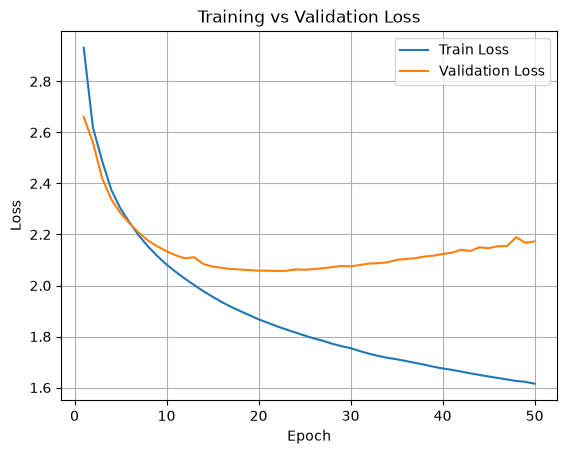

In [28]:
# 绘制 loss 曲线
plt.plot(range(1, len(train_losses) + 1), train_losses, label="Train Loss")
plt.plot(range(1, len(val_losses) + 1), val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid()
plt.show()

# 步骤三：生成诗歌

In [29]:
def generate(model, start_words, ix2word, word2ix, max_gen_len, prefix_words=None):
    """给定几个词，根据这几个词接着生成一首完整的诗歌"""
    results = list(start_words)
    start_words_len = len(start_words)
    # 手动设置第一个词为<START>
    input = torch.Tensor([word2ix['<START>']]).view(1,1).long().to(device)      # tensor([8291.]) → tensor([[8291.]]) → tensor([[8291]])
    hidden = None

    if prefix_words :
        for word in prefix_words:
            output, hidden = model(input, hidden)
            input = input.data.new([word2ix[word]]).view(1, 1).to(device)

    for i in range(max_gen_len):      # 最大生成长度
        output, hidden = model(input, hidden)

        if i < start_words_len:
            w = start_words[i]
            input = input.data.new([word2ix[w]]).view(1, 1)
        else:
            # 用预测的词作为新的输入，计算隐藏元和预测新的输出
            top_index = output.data[0].topk(1)[1][0]
            w = ix2word[top_index.item()] #TODO，书上是没有item()的
            results.append(w)
            input = input.data.new([top_index]).view(1, 1)
        if w == '<EOP>':
            break
    return results

In [30]:
def gen_acrostic(model, start_words, ix2word, word2ix, max_gen_len, prefix_words=None):
    """生成藏头诗"""
    results = []
    start_words_len = len(start_words)  # 要生成的句子的数量
    input = torch.Tensor([word2ix['<START>']]).view(1, 1).long().to(device)
    hidden = None

    index = 0  # 用来指示已经生成了多少句藏头诗
    pre_word = '<START>'  # 上一个词

    if prefix_words :
        for word in prefix_words:
            output, hidden = model(input, hidden)
            input = input.data.new([word2ix[word]]).view(1, 1).to(device)

    for i in range(max_gen_len):
        # 前向计算出概率最大的当前词
        output, hidden = model(input, hidden)
        top_index = output.data[0].topk(1)[1][0]
        w = ix2word[top_index.item()] # TODO:书上没有item()

        # 句首的字用藏头字代替
        if (pre_word in {'。', '! ', '<START>'}): #python3开始默认u
            #  如采遇到句号、感叹号等，把藏头的词作为下一个句的输入
            if index == start_words_len:
                # 如果生成的诗歌已经包含全部藏头的词，则结束
                break
            else:
                # 把藏头的词作为输入， 预测下一个词
                w = start_words[index]
                index += 1
                input = torch.Tensor([word2ix[w]]).view(1, 1).long().to(device)
        else:
            input = torch.Tensor([top_index]).view(1, 1).long().to(device)

        results.append(w)
        pre_word = w

    return results

基于你训练好的模型，测试生成藏头诗（`start_words = '深度学习' `）和续写古诗（`start_words = '大漠孤烟照高阁'`）。

In [31]:
# 生成诗歌相关配置
prefix_words = '江流天地外，山色有无中。'  # 不是诗歌的组成部分，用来控制生成诗歌的意境
max_gen_len = 200  # 生成诗歌最长长度

In [32]:
# 加载已保存的最终模型
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = PoetryModel(vocab_size, embedding_dim, hidden_dim, layer_num)
model.load_state_dict(torch.load(model_path, map_location=device, weights_only=True))
model.to(device)
model.eval()

PoetryModel(
  (embeddings): Embedding(8941, 256)
  (lstm): LSTM(256, 256, num_layers=2)
  (linear1): Linear(in_features=256, out_features=8941, bias=True)
)

In [33]:
start_words = '深度学习'
result = gen_acrostic(model, start_words, ix2word, word2ix, max_gen_len, prefix_words)
print (''. join(result)) 

深谷连山寺，余花入洞宫。度云开古壑，开日映东风。学道乾坤妙，神仙自有风。习亲同凤沼，分赏托丹霄。


In [34]:
start_words = '大漠孤烟照高阁'
result = generate(model, start_words, ix2word, word2ix, max_gen_len, prefix_words)
print (''. join(result)) 

大漠孤烟照高阁，遥闻竹下清江风。南湖风景纷纷荡，白云相思何悠悠。青山峨峨连天台，白云飞处空见楼。江山不见君子后，君子还同一樽酒。古来不见有诗意，不是相思不相见。君不见，梦想思君去，白日如霜落如雪。海边花鸟多逸人，夜上西楼月明月。此时此会不相思，空使狂风吹我泪。不如今日送归客，不惜黄金买书客。夜深风起月如丝，月下江边花不落。<EOP>


# 步骤四：大语言模型生成诗歌

使用Hugging Face的开源大模型，或通过openai API调用gpt系列模型。

自行设计prompt，测试生成藏头诗（`start_words = '深度学习' `）和续写古诗（`start_words = '大漠孤烟照高阁'`）；

使用Chat GPT 5.5模型测试：

```
>>> 生成一首以“深度学习”为头的藏头诗
<<< 深研万象悟玄机，
度越千重见理微。
学海无涯勤探索，
习成智能启新晖。
```

```
>>> 以“大漠孤烟照高阁”为起始句续写一首古诗
<<< 大漠孤烟照高阁，
长河落日映寒波。
边城暮角催征雁，
古道西风起战歌。
万里关山连塞草，
千秋剑气入银河。
凭栏莫问兴亡事，
一片苍茫月更多。
```